In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
import ast
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import coo_matrix
from collections import defaultdict



In [2]:
# Load the data
games_processed_all = pd.read_pickle("games_processed.pkl")
recommendations_df = pd.read_pickle("recommendations_processed.pkl")


In [3]:
def create_cold_start_split(recommendations_df, test_size=0.15, val_size=0.15,
                            timestamp_col='date', cold_start_user_frac=0.01, seed=42):
    np.random.seed(seed)

    # Sort by timestamp if available
    if timestamp_col in recommendations_df.columns:
        recommendations_df = recommendations_df.sort_values(timestamp_col)

    # Identify cold-start users
    all_users = recommendations_df['user_id'].unique()
    n_cold_users = int(len(all_users) * cold_start_user_frac)
    cold_users = np.random.choice(all_users, size=n_cold_users, replace=False)

    # Cold-start test data
    cold_user_df = recommendations_df[recommendations_df['user_id'].isin(cold_users)]

    # Remove cold users from the remaining dataset
    warm_df = recommendations_df[~recommendations_df['user_id'].isin(cold_users)]

    # Split warm_df by user chronologically
    user_groups = warm_df.groupby('user_id')

    train_data = []
    val_data = []
    test_data = []

    for user_id, user_data in user_groups:
        n = len(user_data)
        if n < 3:
            continue

        n_test = max(1, int(n * test_size))
        n_val = max(1, int(n * val_size))

        user_train = user_data.iloc[:-n_test-n_val]
        user_val = user_data.iloc[-n_test-n_val:-n_test]
        user_test = user_data.iloc[-n_test:]

        train_data.append(user_train)
        val_data.append(user_val)
        test_data.append(user_test)

    train_df = pd.concat(train_data)
    val_df = pd.concat(val_data)
    test_df = pd.concat(test_data)

    return train_df, val_df, test_df, cold_user_df

train_df, val_df, test_df, cold_user_df = create_cold_start_split(recommendations_df)

In [4]:
# Cell 2 - Content-Based Model Setup (MLPRegressor Autoencoder)
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

# Prepare the data for autoencoder
def prepare_autoencoder_data():
    # Create a binary matrix of games and their tags
    all_tags = set()
    for tags in games_processed_all['tags']:
        all_tags.update(tags)
    
    tag_to_idx = {tag: idx for idx, tag in enumerate(sorted(all_tags))}
    
    # Create binary matrix
    game_tag_matrix = np.zeros((len(games_processed_all), len(tag_to_idx)))
    for i, tags in enumerate(games_processed_all['tags']):
        for tag in tags:
            if tag in tag_to_idx:
                game_tag_matrix[i, tag_to_idx[tag]] = 1
    
    return game_tag_matrix, tag_to_idx

# Build and train autoencoder using MLPRegressor
def build_autoencoder(input_dim, encoding_dim=128):
    # Create the autoencoder model
    autoencoder = MLPRegressor(
        hidden_layer_sizes=(256, encoding_dim, 256),
        activation='relu',
        solver='adam',
        learning_rate='constant',
        learning_rate_init=0.001,
        max_iter=50,
        batch_size=256,
        random_state=42
    )
    
    return autoencoder

# Prepare data and train autoencoder
game_tag_matrix, tag_to_idx = prepare_autoencoder_data()

# Scale the input data
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(game_tag_matrix)

# Train the autoencoder
autoencoder = build_autoencoder(game_tag_matrix.shape[1])
autoencoder.fit(scaled_matrix, scaled_matrix)

# Create game embeddings using the hidden layer
# We'll use the middle layer (encoding_dim) as our embeddings
game_embeddings = autoencoder.predict(scaled_matrix)
game_embeddings_df = pd.DataFrame(
    game_embeddings,
    index=games_processed_all['app_id']
)

# Build user profiles using autoencoder embeddings
user_profiles_autoencoder = {}
for user_id in train_df["user_id"].unique():
    app_ids = train_df[train_df["user_id"] == user_id]["app_id"]
    valid_ids = app_ids[app_ids.isin(game_embeddings_df.index)]
    vectors = game_embeddings_df.loc[valid_ids]
    if not vectors.empty:
        user_profiles_autoencoder[user_id] = vectors.mean(axis=0).values.reshape(1, -1)

In [5]:
# Fit encoders on training data
user_enc = LabelEncoder()
item_enc = LabelEncoder()

train_df['user_idx'] = user_enc.fit_transform(train_df['user_id'])
train_df['item_idx'] = item_enc.fit_transform(train_df['app_id'])

# For validation and test, only keep users/items seen in training
val_df = val_df[val_df['user_id'].isin(user_enc.classes_)]
val_df = val_df[val_df['app_id'].isin(item_enc.classes_)]
val_df['user_idx'] = user_enc.transform(val_df['user_id'])
val_df['item_idx'] = item_enc.transform(val_df['app_id'])

test_df = test_df[test_df['user_id'].isin(user_enc.classes_)]
test_df = test_df[test_df['app_id'].isin(item_enc.classes_)]
test_df['user_idx'] = user_enc.transform(test_df['user_id'])
test_df['item_idx'] = item_enc.transform(test_df['app_id'])


train_matrix = coo_matrix(
    (train_df['rating'], (train_df['user_idx'], train_df['item_idx']))
).tocsr()


In [6]:
class KNNRecommender:
    def __init__(self, n_neighbors=5, top_n=5, metric='cosine', algorithm='brute', eps=1e-6):
        self.n_neighbors = n_neighbors
        self.top_n = top_n
        self.metric = metric
        self.algorithm = algorithm
        self.eps = eps

    def fit(self, X):
        self.X_ = X
        self.n_users_, _ = X.shape
        self.knn_ = NearestNeighbors(
            n_neighbors=self.n_neighbors,
            metric=self.metric,
            algorithm=self.algorithm
        ).fit(X)
        return self

    def predict(self):
        preds = {}
        for u in range(self.n_users_):
            dists, nbrs = self.knn_.kneighbors(self.X_[u], n_neighbors=self.n_neighbors)
            dists = dists[0][1:]  # drop self
            nbrs = nbrs[0][1:]
            if self.metric == 'cosine':
                sims = 1.0 - dists
            else:
                sims = 1.0 / (dists + self.eps)
            neighbor_matrix = self.X_[nbrs]
            weighted_matrix = neighbor_matrix.multiply(sims[:, None])
            scores = weighted_matrix.sum(axis=0).A1
            seen = self.X_[u].toarray().ravel() > 0
            scores[seen] = 0.0
            top_items = np.argsort(scores)[::-1][:self.top_n]
            preds[u] = set(top_items)
        return preds

In [7]:
knn_model = NearestNeighbors(metric='euclidean', algorithm='brute', n_neighbors=100)
knn_model.fit(train_matrix)

NearestNeighbors(algorithm='brute', metric='euclidean', n_neighbors=100)

In [8]:
def hybrid_recommend(user_id, top_n=5, content_weight=0.5, collab_weight=0.5):
    try:
        # Initialize scores dictionary
        game_scores = {}
        
        # Content-based recommendations using autoencoder
        if user_id in user_profiles_autoencoder:
            user_vector = user_profiles_autoencoder[user_id]
            content_similarities = cosine_similarity(user_vector, game_embeddings).flatten()
            
            # Normalize content scores
            content_scores = (content_similarities - content_similarities.min()) / (content_similarities.max() - content_similarities.min())
            
            for idx, app_id in enumerate(game_embeddings_df.index):
                game_scores[app_id] = content_scores[idx] * content_weight
        else:
            # Fallback for content-based: use games sorted by rating and then user_reviews
            fallback = games_processed_all.sort_values(
                by=['rating', 'user_reviews'],
                ascending=[False, False]
            ).head(top_n)
            
            for _, row in fallback.iterrows():
                game_scores[row['app_id']] = 1.0 * content_weight
        
        # Collaborative filtering recommendations
        if user_id in user_enc.classes_:
            user_idx = user_enc.transform([user_id])[0]
            distances, indices = knn_model.kneighbors(train_matrix[user_idx], n_neighbors=100)
            
            # Get similar users' game preferences
            similar_users = user_enc.inverse_transform(indices[0][1:])  # Exclude the user themselves
            similar_users_preferences = train_matrix[user_enc.transform(similar_users)]
            
            # Calculate collaborative scores
            collab_scores = similar_users_preferences.mean(axis=0).A1
            
            # Normalize collaborative scores
            if len(collab_scores) > 0 and (collab_scores.max() - collab_scores.min()) > 0:
                collab_scores = (collab_scores - collab_scores.min()) / (collab_scores.max() - collab_scores.min())
            
            # Add collaborative scores to game scores
            for idx, app_id in enumerate(item_enc.classes_):
                if app_id in game_scores:
                    game_scores[app_id] += collab_scores[idx] * collab_weight
                else:
                    game_scores[app_id] = collab_scores[idx] * collab_weight
        else:
            # Fallback for collaborative filtering: use games with highest number of recommendations
            game_recommendations = train_df[train_df['is_recommended'] == True].groupby('app_id').size()
            game_recommendations = game_recommendations.sort_values(ascending=False)
            collab_fallback = game_recommendations.head(top_n)
            
            for app_id in collab_fallback.index:
                if app_id in game_scores:
                    game_scores[app_id] += 1.0 * collab_weight
                else:
                    game_scores[app_id] = 1.0 * collab_weight
        
        # Get played games
        played = set(train_df[train_df["user_id"] == user_id]["app_id"])
        
        # Remove played games and sort by score
        recommendations = [(app_id, score) for app_id, score in game_scores.items() 
                          if app_id not in played]
        
        if not recommendations:
            print(f"No recommendations found for user {user_id}")
            return pd.DataFrame(columns=['app_id', 'score'])
            
        recommendations.sort(key=lambda x: x[1], reverse=True)
        
        # Get top N recommendations
        top_recommendations = recommendations[:top_n]
        
        # Convert to DataFrame format
        recommendations_df = pd.DataFrame(top_recommendations, columns=['app_id', 'score'])
        return recommendations_df
        
    except Exception as e:
        print(f"Error processing user {user_id}: {str(e)}")
        print(f"Error type: {type(e)}")
        import traceback
        print(traceback.format_exc())
        return pd.DataFrame(columns=['app_id', 'score'])

In [9]:
def calculate_ndcg(relevant_items, recommended_items, k=5):
    if len(recommended_items) == 0:
        return 0.0
    
    # Calculate DCG
    dcg = 0.0
    for i, item in enumerate(recommended_items[:k]):
        if item in relevant_items:
            dcg += 1.0 / np.log2(i + 2)
    
    # Calculate IDCG
    idcg = 0.0
    num_relevant = min(len(relevant_items), k)
    for i in range(num_relevant):
        idcg += 1.0 / np.log2(i + 2)
    
    # Calculate NDCG
    ndcg = dcg / idcg if idcg > 0 else 0.0
    return ndcg

def calculate_f1(precision, recall):
    if precision + recall == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)

def evaluate_recommendations_enhanced(recommender_func, test_df, cold_user_df=None, top_n=5):
    # Evaluate on regular test set
    test_users = test_df['user_id'].unique()
    test_metrics = []
    
    for user_id in test_users:
        user_test_games = set(test_df[test_df['user_id'] == user_id]['app_id'])
        recommendations = recommender_func(user_id, top_n=top_n)
        recommended_games = list(recommendations['app_id'])
        
        # Calculate basic metrics
        hits = len(user_test_games.intersection(recommended_games))
        precision = hits / top_n if top_n > 0 else 0
        recall = hits / len(user_test_games) if len(user_test_games) > 0 else 0
        f1 = calculate_f1(precision, recall)
        
        # Calculate NDCG
        ndcg = calculate_ndcg(user_test_games, recommended_games, k=top_n)
        
        test_metrics.append({
            'user_id': user_id,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'ndcg': ndcg
        })
    
    # Evaluate on cold-start users if provided
    cold_metrics = []
    if cold_user_df is not None:
        cold_users = cold_user_df['user_id'].unique()
        for user_id in cold_users:
            user_test_games = set(cold_user_df[cold_user_df['user_id'] == user_id]['app_id'])
            recommendations = recommender_func(user_id, top_n=top_n)
            recommended_games = list(recommendations['app_id'])
            
            hits = len(user_test_games.intersection(recommended_games))
            precision = hits / top_n if top_n > 0 else 0
            recall = hits / len(user_test_games) if len(user_test_games) > 0 else 0
            f1 = calculate_f1(precision, recall)
            
            # Calculate NDCG
            ndcg = calculate_ndcg(user_test_games, recommended_games, k=top_n)
            
            cold_metrics.append({
                'user_id': user_id,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'ndcg': ndcg
            })
    
    # Calculate average metrics
    test_metrics_df = pd.DataFrame(test_metrics)
    cold_metrics_df = pd.DataFrame(cold_metrics)
    
    results = {
        'test_set': {
            'avg_precision': test_metrics_df['precision'].mean(),
            'avg_recall': test_metrics_df['recall'].mean(),
            'avg_f1': test_metrics_df['f1'].mean(),
            'avg_ndcg': test_metrics_df['ndcg'].mean()
        }
    }
    
    if cold_metrics:
        results['cold_start'] = {
            'avg_precision': cold_metrics_df['precision'].mean(),
            'avg_recall': cold_metrics_df['recall'].mean(),
            'avg_f1': cold_metrics_df['f1'].mean(),
            'avg_ndcg': cold_metrics_df['ndcg'].mean()
        }
    
    return results

Starting hybrid weight tuning with 11 combinations...


  9%|▉         | 1/11 [06:55<1:09:10, 415.04s/it]


Weights - Content: 0.00, Collab: 1.00
Metrics: {'avg_precision': 0.01335583553990696, 'avg_recall': 0.06607238797345986, 'avg_f1': 0.02216252850642251, 'avg_ndcg': 0.045586228105516984}
Time taken: 415.04 seconds


 18%|█▊        | 2/11 [12:59<57:50, 385.56s/it]  


Weights - Content: 0.10, Collab: 0.90
Metrics: {'avg_precision': 0.005778799429685374, 'avg_recall': 0.02865144719394436, 'avg_f1': 0.009597145646339067, 'avg_ndcg': 0.021089097056264685}
Time taken: 364.92 seconds


...


Weights - Content: 0.80, Collab: 0.20
Metrics: {'avg_precision': 0.0024442051968458305, 'avg_recall': 0.011955197885014276, 'avg_f1': 0.0040356089008177125, 'avg_ndcg': 0.008072754553657016}
Time taken: 272.80 seconds


 91%|█████████ | 10/11 [58:32<05:09, 309.90s/it]


Weights - Content: 0.90, Collab: 0.10
Metrics: {'avg_precision': 0.002321994937003538, 'avg_recall': 0.011344146585802822, 'avg_f1': 0.0038319251344138892, 'avg_ndcg': 0.007645235067239465}
Time taken: 267.81 seconds


100%|██████████| 11/11 [1:03:30<00:00, 346.43s/it]


Weights - Content: 1.00, Collab: 0.00
Metrics: {'avg_precision': 0.0022754386475398077, 'avg_recall': 0.011111365138484175, 'avg_f1': 0.003754331318641004, 'avg_ndcg': 0.007406667318012744}
Time taken: 298.72 seconds

Best weights found:
Content weight: 0.00
Collaborative weight: 1.00
Metrics: {'avg_precision': 0.01335583553990696, 'avg_recall': 0.06607238797345986, 'avg_f1': 0.02216252850642251, 'avg_ndcg': 0.045586228105516984}

Detailed Results:

Weights - Content: 0.00, Collab: 1.00
Metrics: {'avg_precision': 0.01335583553990696, 'avg_recall': 0.06607238797345986, 'avg_f1': 0.02216252850642251, 'avg_ndcg': 0.045586228105516984}
Time taken: 415.04 seconds

Weights - Content: 0.10, Collab: 0.90
Metrics: {'avg_precision': 0.005778799429685374, 'avg_recall': 0.02865144719394436, 'avg_f1': 0.009597145646339067, 'avg_ndcg': 0.021089097056264685}
Time taken: 364.92 seconds

Weights - Content: 0.20, Collab: 0.80
Metrics: {'avg_precision': 0.004172607443186789, 'avg_recall': 0.020597209116

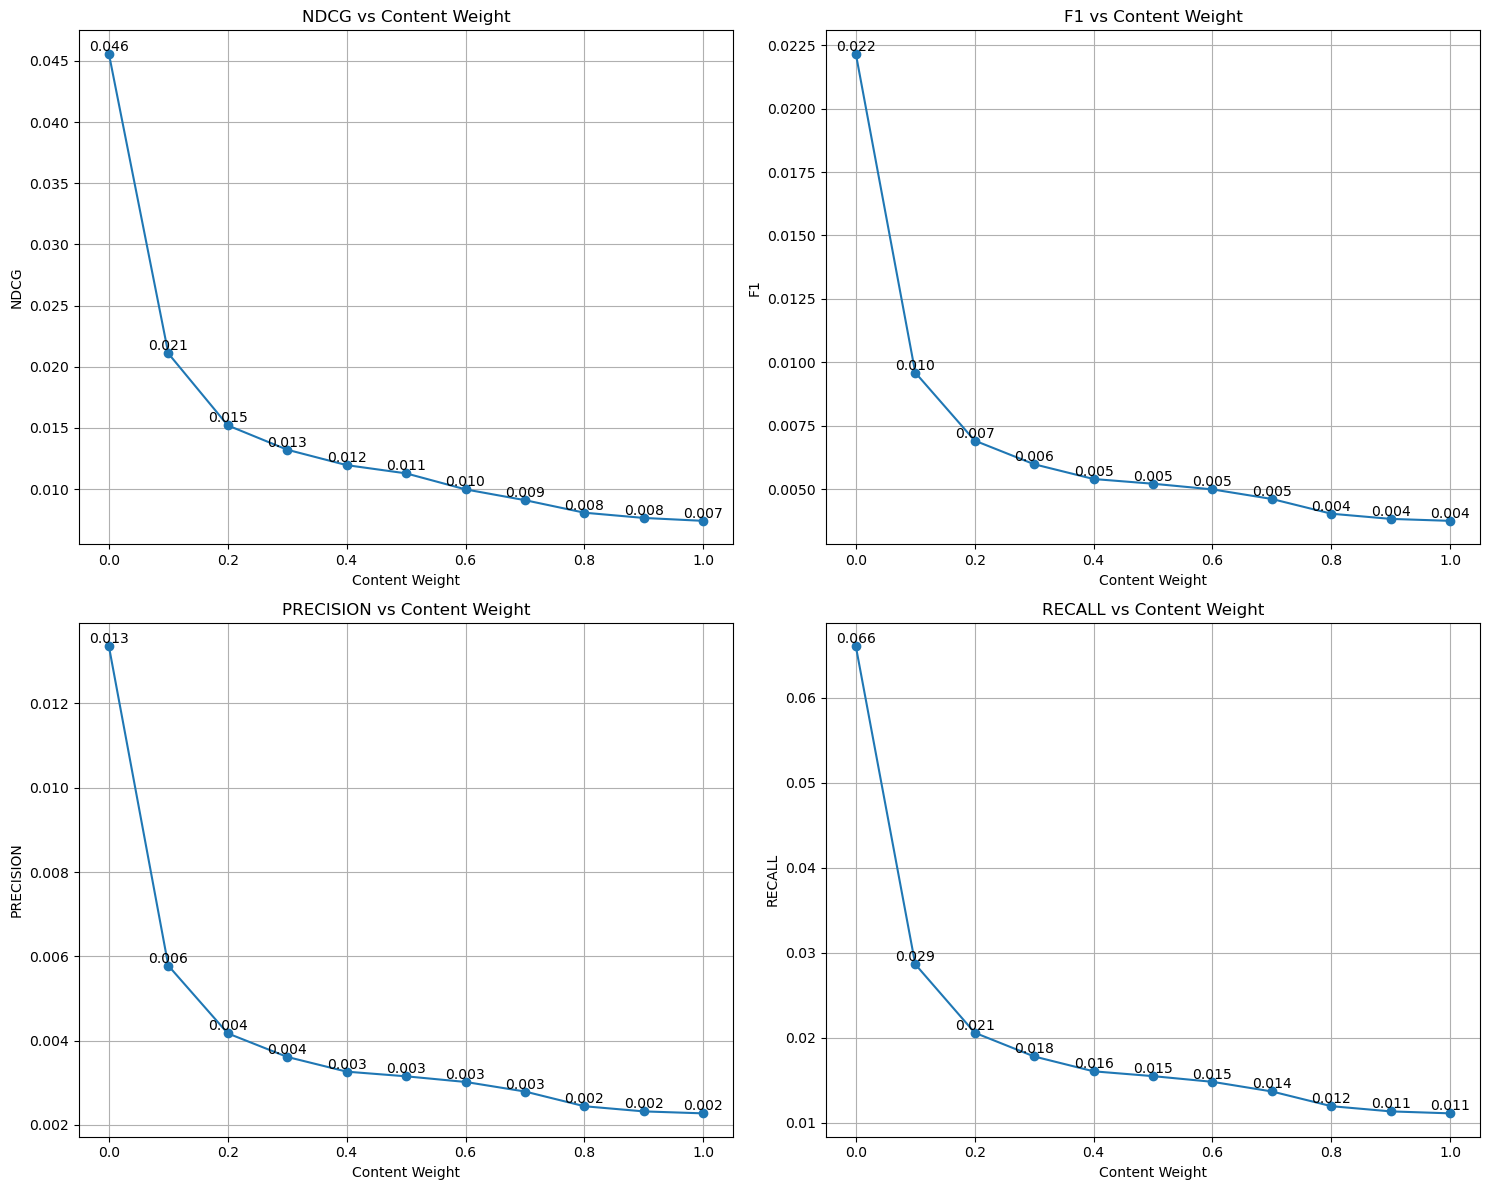


Best weight combinations:

Best NDCG:
Content weight: 0.00
Collaborative weight: 1.00
NDCG: 0.046

Best F1:
Content weight: 0.00
Collaborative weight: 1.00
F1: 0.022


In [10]:
# Cell for Hybrid Model Hyperparameter Tuning
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm
import time

def evaluate_hybrid_weights(content_weight, collab_weight, train_df, val_df, top_n=5):
    """
    Evaluate a single set of hybrid weights
    """
    try:
        # Evaluate on validation set
        val_users = val_df['user_id'].unique()
        total_ndcg = 0
        total_precision = 0
        total_recall = 0
        total_f1 = 0
        processed_users = 0
        
        for user_id in val_users:
            try:
                user_val_games = set(val_df[val_df['user_id'] == user_id]['app_id'])
                
                # Get recommendations with current weights
                recommendations = hybrid_recommend(
                    user_id, 
                    top_n=top_n,
                    content_weight=content_weight,
                    collab_weight=collab_weight
                )
                
                if not recommendations.empty:
                    recommended_games = list(recommendations['app_id'])
                    
                    # Calculate metrics
                    hits = len(user_val_games.intersection(recommended_games))
                    precision = hits / top_n if top_n > 0 else 0
                    recall = hits / len(user_val_games) if len(user_val_games) > 0 else 0
                    f1 = calculate_f1(precision, recall)
                    ndcg = calculate_ndcg(user_val_games, recommended_games, k=top_n)
                    
                    total_precision += precision
                    total_recall += recall
                    total_f1 += f1
                    total_ndcg += ndcg
                    processed_users += 1
            except Exception as e:
                print(f"Error processing user {user_id}: {str(e)}")
                continue
        
        if processed_users == 0:
            print("No users were successfully processed")
            return {
                'avg_precision': 0,
                'avg_recall': 0,
                'avg_f1': 0,
                'avg_ndcg': 0
            }
        
        avg_precision = total_precision / processed_users
        avg_recall = total_recall / processed_users
        avg_f1 = total_f1 / processed_users
        avg_ndcg = total_ndcg / processed_users
        
        return {
            'avg_precision': avg_precision,
            'avg_recall': avg_recall,
            'avg_f1': avg_f1,
            'avg_ndcg': avg_ndcg
        }
        
    except Exception as e:
        print(f"Error in evaluate_hybrid_weights: {str(e)}")
        print(f"Error type: {type(e)}")
        import traceback
        print(traceback.format_exc())
        return {
            'avg_precision': 0,
            'avg_recall': 0,
            'avg_f1': 0,
            'avg_ndcg': 0
        }

def tune_hybrid_weights(train_df, val_df, weight_range, top_n=5):
    """
    Perform grid search for hybrid weight tuning
    """
    results = []
    
    # Create parameter grid with complementary weights
    param_grid = []
    for content_weight in weight_range:
        collab_weight = 1.0 - content_weight
        param_grid.append({
            'content_weight': content_weight,
            'collab_weight': collab_weight
        })
    
    total_combinations = len(param_grid)
    print(f"Starting hybrid weight tuning with {total_combinations} combinations...")
    
    for params in tqdm(param_grid):
        start_time = time.time()
        
        # Evaluate current weight combination
        metrics = evaluate_hybrid_weights(
            params['content_weight'],
            params['collab_weight'],
            train_df,
            val_df,
            top_n
        )
        
        # Store results
        result = {
            'params': params,
            'metrics': metrics,
            'time_taken': time.time() - start_time
        }
        results.append(result)
        
        print(f"\nWeights - Content: {params['content_weight']:.2f}, Collab: {params['collab_weight']:.2f}")
        print(f"Metrics: {metrics}")
        print(f"Time taken: {result['time_taken']:.2f} seconds")
    
    # Find best parameters based on NDCG
    best_result = max(results, key=lambda x: x['metrics']['avg_ndcg'])
    
    print("\nBest weights found:")
    print(f"Content weight: {best_result['params']['content_weight']:.2f}")
    print(f"Collaborative weight: {best_result['params']['collab_weight']:.2f}")
    print(f"Metrics: {best_result['metrics']}")
    
    return best_result, results

# Define weight range to test
weight_range = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

# Run hybrid weight tuning
best_result, all_results = tune_hybrid_weights(train_df, val_df, weight_range)

# Print detailed results
print("\nDetailed Results:")
for result in all_results:
    print(f"\nWeights - Content: {result['params']['content_weight']:.2f}, Collab: {result['params']['collab_weight']:.2f}")
    print(f"Metrics: {result['metrics']}")
    print(f"Time taken: {result['time_taken']:.2f} seconds")

# Create a DataFrame for visualization
results_df = pd.DataFrame([
    {
        'content_weight': r['params']['content_weight'],
        'collab_weight': r['params']['collab_weight'],
        'ndcg': r['metrics']['avg_ndcg'],
        'f1': r['metrics']['avg_f1'],
        'precision': r['metrics']['avg_precision'],
        'recall': r['metrics']['avg_recall']
    }
    for r in all_results
])

# Visualize results
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

# Plot metrics against content weight
metrics = ['ndcg', 'f1', 'precision', 'recall']
for idx, metric in enumerate(metrics):
    axes[idx].plot(results_df['content_weight'], results_df[metric], marker='o')
    axes[idx].set_xlabel('Content Weight')
    axes[idx].set_ylabel(metric.upper())
    axes[idx].set_title(f'{metric.upper()} vs Content Weight')
    axes[idx].grid(True)
    
    # Add value labels on points
    for x, y in zip(results_df['content_weight'], results_df[metric]):
        axes[idx].text(x, y, f'{y:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print the best weight combinations for each metric
print("\nBest weight combinations:")
print("\nBest NDCG:")
best_ndcg = results_df.loc[results_df['ndcg'].idxmax()]
print(f"Content weight: {best_ndcg['content_weight']:.2f}")
print(f"Collaborative weight: {best_ndcg['collab_weight']:.2f}")
print(f"NDCG: {best_ndcg['ndcg']:.3f}")

print("\nBest F1:")
best_f1 = results_df.loc[results_df['f1'].idxmax()]
print(f"Content weight: {best_f1['content_weight']:.2f}")
print(f"Collaborative weight: {best_f1['collab_weight']:.2f}")
print(f"F1: {best_f1['f1']:.3f}")

In [11]:
def evaluate_scenario(recommender_func, test_df, scenario_name, top_n=5):
    """
    Evaluate a specific recommendation scenario
    """
    test_users = test_df['user_id'].unique()
    metrics = []
    
    for user_id in test_users:
        user_test_games = set(test_df[test_df['user_id'] == user_id]['app_id'])
        recommendations = recommender_func(user_id, top_n=top_n)
        
        if recommendations is not None:
            recommended_games = list(recommendations['app_id'])
            
            # Calculate metrics
            hits = len(user_test_games.intersection(recommended_games))
            precision = hits / top_n if top_n > 0 else 0
            recall = hits / len(user_test_games) if len(user_test_games) > 0 else 0
            f1 = calculate_f1(precision, recall)
            ndcg = calculate_ndcg(user_test_games, recommended_games, k=top_n)
            
            metrics.append({
                'user_id': user_id,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'ndcg': ndcg
            })
    
    metrics_df = pd.DataFrame(metrics)
    avg_metrics = {
        'scenario': scenario_name,
        'avg_precision': metrics_df['precision'].mean(),
        'avg_recall': metrics_df['recall'].mean(),
        'avg_f1': metrics_df['f1'].mean(),
        'avg_ndcg': metrics_df['ndcg'].mean()
    }
    
    return avg_metrics

Using best weights from tuning:
Content weight: 0.00
Collaborative weight: 1.00

Combined training set size: 112962

Retraining content-based model...
Building user profiles...
Retraining collaborative filtering model...

Evaluating on regular test set...
Evaluating on cold-start users...

Final Model Results:

Regular Test Set:
   scenario  avg_precision  avg_recall   avg_f1  avg_ndcg
Final Model       0.017636    0.087634 0.029332  0.050428

Cold-Start User Results:
          scenario  avg_precision  avg_recall   avg_f1  avg_ndcg
       Final Model       0.019404    0.078732 0.029934  0.052761
      Content-Only       0.018474    0.080229 0.029270  0.044806
Collaborative-Only       0.019404    0.078732 0.029934  0.052761


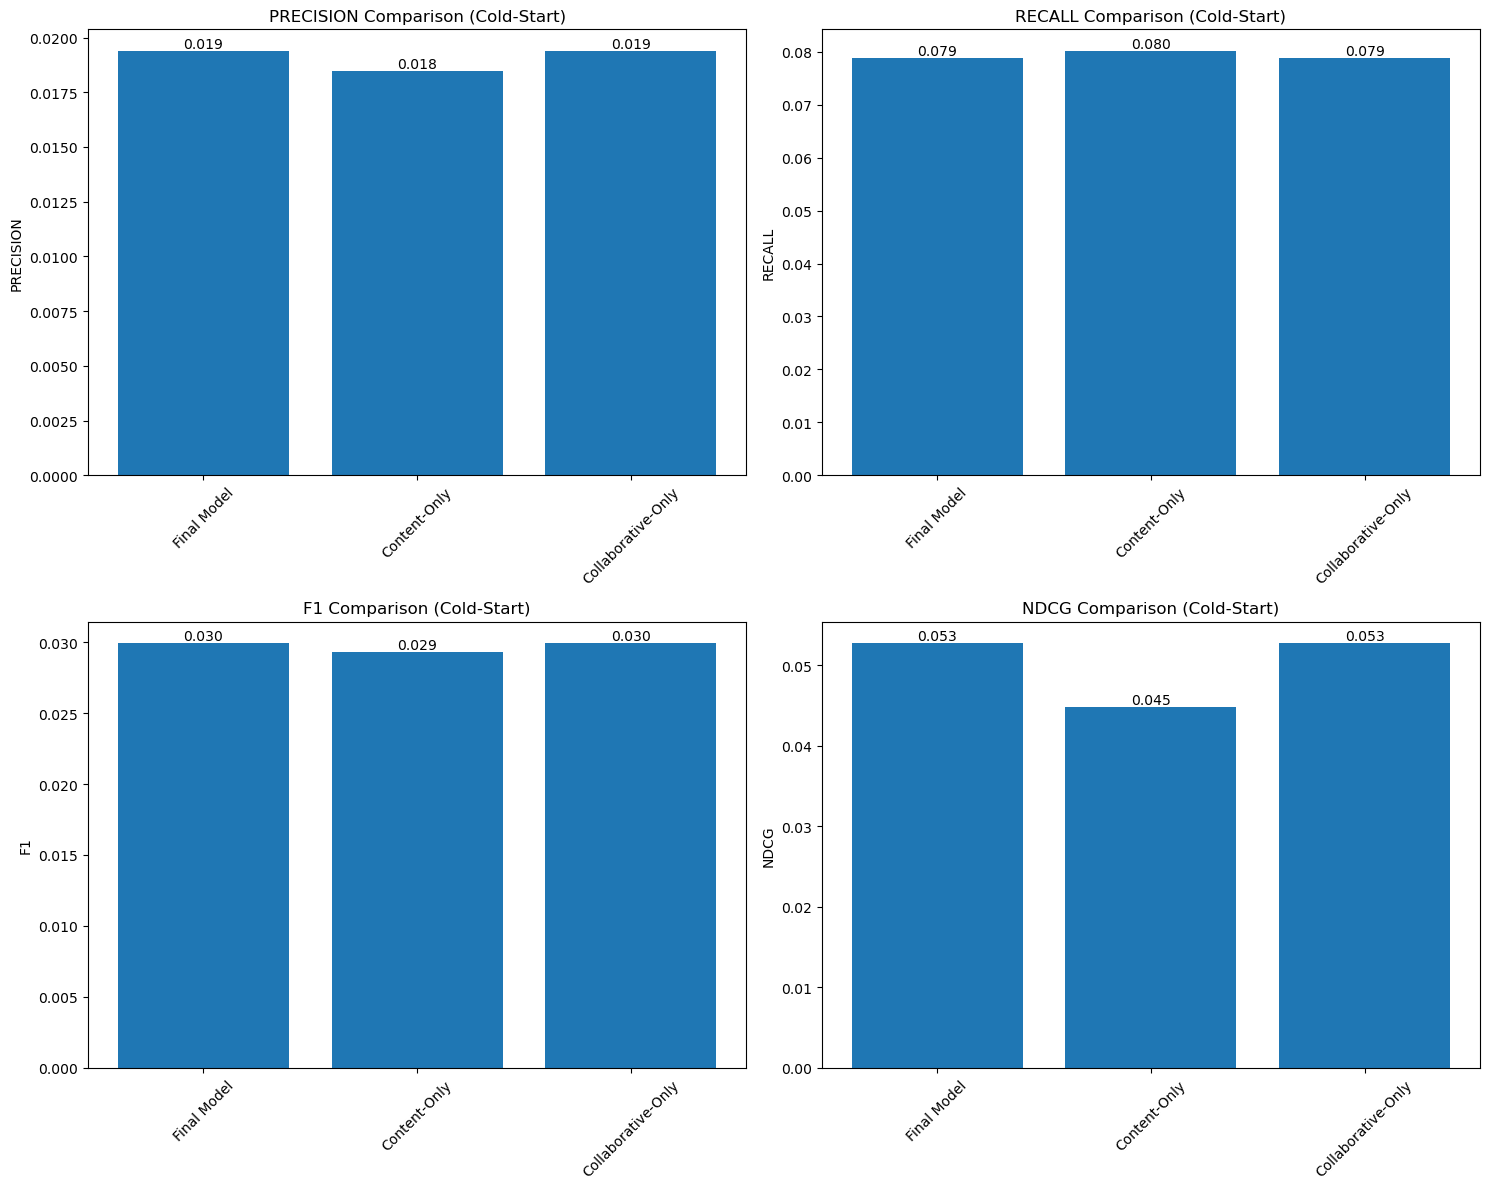


Comparison with Regular Test Set:

PRECISION:
Regular Test: 0.018
Cold-Start Scenarios:
Final Model: 0.019
Content-Only: 0.018
Collaborative-Only: 0.019

RECALL:
Regular Test: 0.088
Cold-Start Scenarios:
Final Model: 0.079
Content-Only: 0.080
Collaborative-Only: 0.079

F1:
Regular Test: 0.029
Cold-Start Scenarios:
Final Model: 0.030
Content-Only: 0.029
Collaborative-Only: 0.030

NDCG:
Regular Test: 0.050
Cold-Start Scenarios:
Final Model: 0.053
Content-Only: 0.045
Collaborative-Only: 0.053


In [12]:
# Cell for Final Training and Evaluation with Best Parameters
# Get best weights from previous tuning
best_ndcg_weights = results_df.loc[results_df['ndcg'].idxmax()]
best_content_weight = best_ndcg_weights['content_weight']
best_collab_weight = best_ndcg_weights['collab_weight']

print(f"Using best weights from tuning:")
print(f"Content weight: {best_content_weight:.2f}")
print(f"Collaborative weight: {best_collab_weight:.2f}")

# Combine train and validation sets
combined_train_df = pd.concat([train_df, val_df], ignore_index=True)
print(f"\nCombined training set size: {len(combined_train_df)}")

# Retrain content-based model with combined data
print("\nRetraining content-based model...")
game_tag_matrix, tag_to_idx = prepare_autoencoder_data()
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(game_tag_matrix)

autoencoder = MLPRegressor(
    hidden_layer_sizes=(256, 128, 256),  # Using the same architecture as before
    activation='relu',
    solver='adam',
    learning_rate='constant',
    learning_rate_init=0.001,
    max_iter=50,
    batch_size=256,
    random_state=42
)

autoencoder.fit(scaled_matrix, scaled_matrix)
game_embeddings = autoencoder.predict(scaled_matrix)
game_embeddings_df = pd.DataFrame(
    game_embeddings,
    index=games_processed_all['app_id']
)

# Build user profiles using combined data
print("Building user profiles...")
user_profiles_autoencoder = {}
for user_id in combined_train_df["user_id"].unique():
    app_ids = combined_train_df[combined_train_df["user_id"] == user_id]["app_id"]
    valid_ids = app_ids[app_ids.isin(game_embeddings_df.index)]
    vectors = game_embeddings_df.loc[valid_ids]
    if not vectors.empty:
        user_profiles_autoencoder[user_id] = vectors.mean(axis=0).values.reshape(1, -1)

# Retrain collaborative filtering model with combined data
print("Retraining collaborative filtering model...")

# Create user and item encoders
user_enc = LabelEncoder()
item_enc = LabelEncoder()

# Encode user and item IDs
combined_train_df['user_idx'] = user_enc.fit_transform(combined_train_df['user_id'])
combined_train_df['item_idx'] = item_enc.fit_transform(combined_train_df['app_id'])

# Create sparse matrix using COO format
train_matrix = coo_matrix(
    (combined_train_df['rating'], (combined_train_df['user_idx'], combined_train_df['item_idx']))
).tocsr()

# Create and fit KNN model
knn_model = NearestNeighbors(
    n_neighbors=100,
    metric='euclidean',  # Using cosine similarity as it's better for sparse data
    algorithm='brute'
).fit(train_matrix)

def evaluate_final_model(test_df, cold_user_df, top_n=5):
    """
    Evaluate the final model on both regular test set and cold-start users
    """
    # Define the final recommendation function with best weights
    def final_recommend(user_id, top_n=5):
        return hybrid_recommend(
            user_id, 
            top_n=top_n,
            content_weight=best_content_weight,
            collab_weight=best_collab_weight
        )
    
    # Evaluate on regular test set
    print("\nEvaluating on regular test set...")
    regular_results = evaluate_scenario(final_recommend, test_df, "Final Model")
    regular_results_df = pd.DataFrame([regular_results])
    
    # Evaluate on cold-start users
    print("Evaluating on cold-start users...")
    cold_results = []
    cold_results.append(evaluate_scenario(final_recommend, cold_user_df, "Final Model"))
    cold_results.append(evaluate_scenario(
        lambda user_id, top_n=5: hybrid_recommend(user_id, top_n, content_weight=1.0, collab_weight=0.0),
        cold_user_df, 
        "Content-Only"
    ))
    cold_results.append(evaluate_scenario(
        lambda user_id, top_n=5: hybrid_recommend(user_id, top_n, content_weight=0.0, collab_weight=1.0),
        cold_user_df, 
        "Collaborative-Only"
    ))
    
    cold_results_df = pd.DataFrame(cold_results)
    
    return regular_results_df, cold_results_df

# Evaluate the final model
regular_results_df, cold_results_df = evaluate_final_model(test_df, cold_user_df)

# Print results
print("\nFinal Model Results:")
print("\nRegular Test Set:")
print(regular_results_df.to_string(index=False))
print("\nCold-Start User Results:")
print(cold_results_df.to_string(index=False))

# Visualize results
import matplotlib.pyplot as plt
import seaborn as sns

# Create comparison plots for cold-start scenarios
metrics = ['avg_precision', 'avg_recall', 'avg_f1', 'avg_ndcg']
scenarios = ['Final Model', 'Content-Only', 'Collaborative-Only']

# Create a figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, metric in enumerate(metrics):
    # Create bar plot for cold-start results
    axes[idx].bar(scenarios, cold_results_df[metric])
    axes[idx].set_ylabel(metric.replace('avg_', '').upper())
    axes[idx].set_title(f'{metric.replace("avg_", "").upper()} Comparison (Cold-Start)')
    axes[idx].set_xticklabels(scenarios, rotation=45)
    
    # Add value labels on top of bars
    for i, v in enumerate(cold_results_df[metric]):
        axes[idx].text(i, v, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print comparison with regular test set
print("\nComparison with Regular Test Set:")
for metric in metrics:
    print(f"\n{metric.replace('avg_', '').upper()}:")
    print(f"Regular Test: {regular_results_df[metric].values[0]:.3f}")
    print("Cold-Start Scenarios:")
    for scenario, value in zip(scenarios, cold_results_df[metric]):
        print(f"{scenario}: {value:.3f}")